In [ ]:
ASSIGNMENT 3, A CLASS HIERACHY THAT MODELS VEHICLES REGISTERED IN UGANDA

In [ ]:
Complete solutions for Q1–Q6 with OOP, error handling, mock JSON, pandas, numpy, and matplotlib
## Q1. Vehicle Registry (Uganda)
1. "vehicle" base class with common attributes  
2. Subclasses: "Car", "Truck", "Motorbike"  
3. "calculate_tax()" overridden per type 
4. polymorphism demo: iterate mixed list and call the same method 
5. Save all records to `vehicle_registry.json

from __future__ import annotations
from dataclasses import dataclass, asdict
from abc import ABC, abstractmethod
from typing import List, Dict, Optional, Any
import json, random
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [15]:
from dataclasses import dataclass, asdict
from abc import ABC, abstractmethod
from typing import List
import json

from dataclasses import dataclass, asdict
from abc import ABC, abstractmethod
from typing import List
import json

@dataclass
class Vehicle(ABC):
    plate_number: str
    owner: str
    engine_cc: int
    base_tax: int
    @abstractmethod
    def calculate_tax(self) -> float: ...

@dataclass
class Car(Vehicle):
    passenger_capacity: int
    def calculate_tax(self) -> float:
        return float(self.base_tax + self.engine_cc * 0.05)

@dataclass
class Truck(Vehicle):
    load_capacity: float  # tons
    def calculate_tax(self) -> float:
        return float(self.base_tax + self.load_capacity * 0.1 * 1_000_000)

@dataclass
class Motorbike(Vehicle):
    bike_type: str
    def calculate_tax(self) -> float:
        return float(self.base_tax + 20_000)

registry: List[Vehicle] = [
    Car("UAA123A","Bosco",1800,300_000,5),
    Truck("UAB456B","Pius",3500,500_000,7.5),
    Motorbike("UAC789C","Denis",150,80_000,"boda"),
    Car("UAD111D","Martha",1300,280_000,4),
    Truck("UAE222E","Paul",4200,550_000,12.0),
    Motorbike("UAF333F","Rachael",125,70_000,"private"),
]

print("Q1 — Polymorphic tax computations:")
for v in registry:
    print(f"{v.plate_number:>7} | {v.owner:<8} | {v.__class__.__name__:<10} | UGX {v.calculate_tax():,.2f}")

with open("vehicle_registry.json","w",encoding="utf-8") as f:
    json.dump([{**asdict(v), "tax": v.calculate_tax()} for v in registry], f, indent=2)
print("Saved: vehicle_registry.json")

Q1 — Polymorphic tax computations:
UAA123A | Bosco    | Car        | UGX 300,090.00
UAB456B | Pius     | Truck      | UGX 1,250,000.00
UAC789C | Denis    | Motorbike  | UGX 100,000.00
UAD111D | Martha   | Car        | UGX 280,065.00
UAE222E | Paul     | Truck      | UGX 1,750,000.00
UAF333F | Rachael  | Motorbike  | UGX 90,000.00
Saved: vehicle_registry.json


In [16]:
## Q2. SACCO Member Loan Eligibility 
from abc import ABC, abstractmethod

class Member(ABC):
    def __init__(self, name: str, id_no: str, savings_balance: float):
        self.name = name; self.id_no = id_no; self.savings_balance = float(savings_balance)
    @abstractmethod
    def loan_eligibility(self) -> float: ...
    @staticmethod
    def get_exchange_rate(base="UGX", quote="USD") -> float:
        try:
            import requests
            r = requests.get(f"https://open.er-api.com/v6/latest/{base}", timeout=5)
            r.raise_for_status()
            data = r.json()
            return float(data["rates"][quote])
        except Exception:
            return 1.0/3800.0  # fallback: ~UGX 3800 per USD

class FarmerMember(Member):
    def loan_eligibility(self) -> float: return 6.0 * self.savings_balance

class TraderMember(Member):
    def loan_eligibility(self) -> float: return 4.0 * self.savings_balance

members = [
    FarmerMember("Charlotte","UG1234567",1_500_000),
    TraderMember("Karen","UG7654321",2_000_000),
]

rate = Member.get_exchange_rate("UGX","USD")
print(f"UGX→USD rate used: {rate:.8f} USD per UGX")

rows=[]
for m in members:
    ugx = m.loan_eligibility(); usd = ugx*rate
    rows.append((m.name, m.__class__.__name__, ugx, usd))

for name, typ, ugx, usd in rows:
    print(f"{name:<10} | {typ:<14} | UGX {ugx:,.2f} | USD {usd:,.2f}")

UGX→USD rate used: 0.00028900 USD per UGX
Charlotte  | FarmerMember   | UGX 9,000,000.00 | USD 2,601.00
Karen      | TraderMember   | UGX 8,000,000.00 | USD 2,312.00


In [18]:
# Q3. Traffic Light Management
import random
from datetime import datetime

class TrafficLight:
    def __init__(self, location: str):
        self.location = location
        self.__current_state = "RED"  # encapsulated
    def turn_green(self): self.__current_state = "GREEN"
    def turn_red(self): self.__current_state = "RED"
    def status(self): return self.__current_state

class SmartTrafficLight(TrafficLight):
    @staticmethod
    def sensor_api_mock() -> dict:
        return {"cars_per_minute": random.randint(5,120)}
    def compute_durations(self) -> dict:
        cars = self.sensor_api_mock()["cars_per_minute"]
        green = int(min(120, max(20, cars)))
        red   = int(min(90,  max(20, 140 - cars)))
        return {"green":green, "red":red}

light = SmartTrafficLight("Jinja Road")
print("Q3 — Simulation Logs:")
for _ in range(5):
    d = light.compute_durations()
    light.turn_green()
    ts = datetime.now().strftime("%H:%M")
    print(f"[{ts}] {light.location}: Green for {d['green']}s, Red for {d['red']}s.")
    light.turn_red()

Q3 — Simulation Logs:
[21:24] Jinja Road: Green for 26s, Red for 90s.
[21:24] Jinja Road: Green for 52s, Red for 88s.
[21:24] Jinja Road: Green for 48s, Red for 90s.
[21:24] Jinja Road: Green for 23s, Red for 90s.
[21:24] Jinja Road: Green for 50s, Red for 90s.


In [19]:
## Q4. Student Grading System

import json
from typing import Dict, Any

class Student:
    def __init__(self, student_id: str, name: str, marks: Dict[str, float]):
        self.student_id = student_id; self.name = name; self.marks = marks
    def total(self) -> float: return float(sum(self.marks.values()))
    def average(self) -> float: return self.total()/max(1, len(self.marks))
    def grade(self) -> str:
        a=self.average()
        return "A" if a>=80 else "B" if a>=70 else "C" if a>=60 else "D" if a>=50 else "E" if a>=40 else "F"
    def to_dict(self) -> Dict[str,Any]:
        return {"student_id":self.student_id,"name":self.name,"marks":self.marks,"type":"Student"}

class PostgraduateStudent(Student):
    def __init__(self, student_id, name, marks, research_topic):
        super().__init__(student_id,name,marks); self.research_topic = research_topic
    def evaluate_thesis(self) -> str:
        return "Pass" if self.grade() in {"A","B","C"} and self.marks.get("Research",0)>=60 else "Revise"
    def to_dict(self):
        d = super().to_dict(); d["type"]="PostgraduateStudent"; d["research_topic"]=self.research_topic; return d

s1 = Student("MSCS001","Alex", {"OOP":85,"DSA":78,"ML":88})
s2 = Student("MSCS002","Grace",{"OOP":62,"DSA":71,"ML":69})
p1 = PostgraduateStudent("MSDS101","Sarah",{"OOP":82,"Research":75,"Stats":79},"Dairy Risk Modelling")
p2 = PostgraduateStudent("MSDS102","Brian",{"OOP":58,"Research":55,"Stats":65},"Agri Price Forecasts")

print("Q4 — Coursework & Thesis:")
for stu in [s1,s2,p1,p2]:
    info = f"{stu.student_id} — {stu.name}: grade {stu.grade()} (avg {stu.average():.1f})"
    if isinstance(stu, PostgraduateStudent):
        info += f"; Thesis: {stu.evaluate_thesis()} — Topic: {stu.research_topic}"
    print(info)

with open("students.json","w",encoding="utf-8") as f:
    json.dump([s1.to_dict(), s2.to_dict(), p1.to_dict(), p2.to_dict()], f, indent=2)
print("Saved: students.json")

with open("students.json","r",encoding="utf-8") as f:
    loaded = json.load(f)
print(f"Reloaded {len(loaded)} records.")


Q4 — Coursework & Thesis:
MSCS001 — Alex: grade A (avg 83.7)
MSCS002 — Grace: grade C (avg 67.3)
MSDS101 — Sarah: grade B (avg 78.7); Thesis: Pass — Topic: Dairy Risk Modelling
MSDS102 — Brian: grade D (avg 59.3); Thesis: Revise — Topic: Agri Price Forecasts
Saved: students.json
Reloaded 4 records.


,artist,title,plays,popularity,country
0,Azawi,Repeat It,1250000,92,Uganda
1,Azawi,10 over 10,980000,88,Uganda
2,Sheebah,Nakyuuka,1520000,95,Uganda
3,Sheebah,Yolo,870000,84,Uganda
4,Eddy Kenzo,Sitya Loss,3300000,99,Uganda
5,Eddy Kenzo,Weekend,1100000,90,Uganda


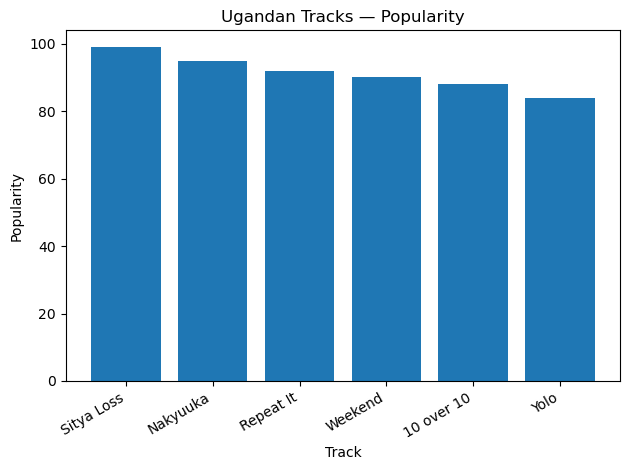

Saved: uganda_music_results.json


In [20]:
## Q5. Uganda Music Analytics (Mocked)

import json, pandas as pd
import matplotlib.pyplot as plt

music = {
    "artists":[
        {"name":"Azawi","tracks":[
            {"title":"Repeat It","plays":1250000,"popularity":92,"country":"Uganda"},
            {"title":"10 over 10","plays":980000,"popularity":88,"country":"Uganda"}]},
        {"name":"Sheebah","tracks":[
            {"title":"Nakyuuka","plays":1520000,"popularity":95,"country":"Uganda"},
            {"title":"Yolo","plays":870000,"popularity":84,"country":"Uganda"}]},
        {"name":"Eddy Kenzo","tracks":[
            {"title":"Sitya Loss","plays":3300000,"popularity":99,"country":"Uganda"},
            {"title":"Weekend","plays":1100000,"popularity":90,"country":"Uganda"}]}
    ]
}

with open("uganda_music_mock.json","w",encoding="utf-8") as f:
    json.dump(music,f,indent=2)

with open("uganda_music_mock.json","r",encoding="utf-8") as f:
    data = json.load(f)

rows=[]
for a in data.get("artists",[]):
    for t in a.get("tracks",[]):
        rows.append({"artist":a["name"], **t})

df = pd.DataFrame(rows)
display(df)

plt.figure()
df_sorted = df.sort_values("popularity", ascending=False)
plt.bar(df_sorted["title"], df_sorted["popularity"])
plt.title("Ugandan Tracks — Popularity")
plt.xlabel("Track"); plt.ylabel("Popularity")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

ug_only = [r for r in rows if r.get("country")=="Uganda"]
with open("uganda_music_results.json","w",encoding="utf-8") as f:
    json.dump({"results":ug_only}, f, indent=2)
print("Saved: uganda_music_results.json")

C:\Users\Pius Ogwal\AppData\Local\Temp\ipykernel_30808\1768358214.py:31: FutureWarning: The provided callable <function mean at 0x00000293E857C4A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  monthly = df.groupby("year_month")[["USD","GBP","EUR"]].agg(np.mean).reset_index()


,year_month,USD,GBP,EUR
0,2025-01,3845.1,4920.0,4150.2
1,2025-02,3860.0,4935.2,4188.7
2,2025-03,3829.5,4882.3,4112.8
3,2025-04,3852.2,4895.1,4135.9
4,2025-05,3875.0,4910.0,4172.0
5,2025-06,3890.0,4930.0,4190.0
6,2025-07,3920.0,4960.0,4210.0
7,2025-08,3910.0,4955.0,4205.0
8,2025-09,3935.0,4975.0,4230.0


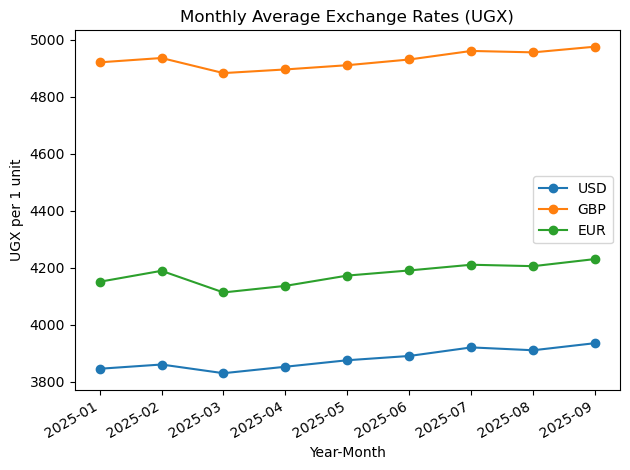

Saved: exrates_monthly.csv, exrates_monthly.json


In [21]:
## Q6. Exchange Rate Pipeline (Mocked JSON)

import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt

mock_rates = {"date":"2025-10-01","rates":[
    {"date":"2025-01-10","USD":3845.1,"GBP":4920.0,"EUR":4150.2},
    {"date":"2025-02-10","USD":3860.0,"GBP":4935.2,"EUR":4188.7},
    {"date":"2025-03-10","USD":3829.5,"GBP":4882.3,"EUR":4112.8},
    {"date":"2025-04-10","USD":3852.2,"GBP":4895.1,"EUR":4135.9},
    {"date":"2025-05-10","USD":3875.0,"GBP":4910.0,"EUR":4172.0},
    {"date":"2025-06-10","USD":3890.0,"GBP":4930.0,"EUR":4190.0},
    {"date":"2025-07-10","USD":3920.0,"GBP":4960.0,"EUR":4210.0},
    {"date":"2025-08-10","USD":3910.0,"GBP":4955.0,"EUR":4205.0},
    {"date":"2025-09-10","USD":3935.0,"GBP":4975.0,"EUR":4230.0},
]}

with open("exchange_rates.json","w",encoding="utf-8") as f:
    json.dump(mock_rates,f,indent=2)

with open("exchange_rates.json","r",encoding="utf-8") as f:
    data = json.load(f)

rates = data.get("rates", [])
if not rates: raise ValueError("No rates found in JSON.")

df = pd.DataFrame(rates)
df["date"] = pd.to_datetime(df["date"])
df["year_month"] = df["date"].dt.to_period("M").astype(str)

monthly = df.groupby("year_month")[["USD","GBP","EUR"]].agg(np.mean).reset_index()
display(monthly)

plt.figure()
for col in ["USD","GBP","EUR"]:
    plt.plot(monthly["year_month"], monthly[col], marker="o", label=col)
plt.title("Monthly Average Exchange Rates (UGX)")
plt.xlabel("Year-Month"); plt.ylabel("UGX per 1 unit")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

monthly.to_csv("exrates_monthly.csv", index=False)
with open("exrates_monthly.json","w",encoding="utf-8") as f:
    json.dump(monthly.to_dict(orient="records"), f, indent=2)
print("Saved: exrates_monthly.csv, exrates_monthly.json")